# Vesuvius Surface Detection — SuPreM SegResNet (Run 10b)

3D segmentation of papyrus surfaces in CT scans of Herculaneum scrolls.

**Metric:** `0.30 * TopoScore + 0.35 * SurfaceDice@tau=2 + 0.35 * VOI_score`

**Changes from Run 10:**
- **Per-module lr_find** — 4 parameter groups (encoder, decoder, new_modules, head) with
  independent lr_find for each. V10 used the same LR=1e-5 as v9, which was tuned for a
  fully pretrained model. The new attention gates + DS heads are randomly initialized and
  need higher LRs. Model peaked at epoch 0 in v10 (never learned), dice dropped from
  0.278 to 0.154, and predicted 0% foreground on test.
- **4-group splitter:** encoder / decoder / new_modules (attn_gates + ds_heads) / head
  (was 3-group with attn_gates lumped into decoder and ds_heads into head)
- **Selective freeze + lr_find:** freeze all but one group, run lr_find, extract valley LR

**Carried from Run 10:**
- Deep supervision (auxiliary loss heads at intermediate decoder levels)
- Attention gates on all 3 skip connections
- Foreground-biased patch sampling (FG_BIAS=0.5)
- 160^3 patches, stride=80 for uniform overlap
- TTA (7-fold) — original + 3 axis flips + 3 HW-plane rotations at inference
- Hysteresis thresholding (T_high=0.85, T_low=0.45)
- Anisotropic closing + dust removal
- Downsampled competition metric (4x -> 80^3)
- Loss: 0.2*BCE + 0.2*Dice + 0.3*clDice + 0.3*Boundary (all masked for label=2)
- MONAI SegResNet (4.7M base params) with SuPreM pre-trained weights

## 1. Imports & Config

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import tifffile
from pathlib import Path
import matplotlib.pyplot as plt
from fastai.learner import Learner
from fastai.callback.schedule import lr_find, fit_one_cycle
from fastai.callback.tracker import SaveModelCallback
from fastai.callback.fp16 import MixedPrecision
from fastai.data.core import DataLoaders
from fastai.metrics import Metric
from monai.networks.nets import SegResNet
from scipy.ndimage import distance_transform_edt, label as scipy_label
from scipy.ndimage import binary_closing
from scipy.ndimage import zoom as scipy_zoom
from scipy.ndimage import generate_binary_structure, binary_propagation
from topometrics.leaderboard import compute_leaderboard_score
import random
import zipfile

# Config
ROOT = Path("/home/mongomatt/Projects/vesuvius")
TRAIN_IMG = ROOT / "train_images"
TRAIN_LBL = ROOT / "train_labels"
TEST_IMG = ROOT / "test_images"
CKPT_DIR = ROOT / "checkpoints"
CKPT_DIR.mkdir(exist_ok=True)
PRETRAINED_WEIGHTS = ROOT / "pretrained_weights" / "supervised_suprem_segresnet_2100.pth"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PATCH_SIZE = 160       # Train on 160^3 random crops (was 128)
STRIDE = 80            # Sliding window stride (uniform 80-voxel overlap)
BATCH_SIZE = 2
NUM_WORKERS = 8
EPOCHS = 30
SEED = 42
N_VAL_VOLUMES = 5      # Number of val volumes for competition metric eval
T_LOW = 0.45           # Hysteresis low threshold
T_HIGH = 0.85          # Hysteresis high threshold (strong seeds)
METRIC_DOWNSAMPLE = 4  # Downsample factor for competition metric (320 -> 80)
CLOSING_Z_RADIUS = 2   # Anisotropic closing: z extent
CLOSING_XY_RADIUS = 1  # Anisotropic closing: xy extent
DUST_MIN_SIZE = 100    # Remove connected components smaller than this
USE_TTA = True         # Test-time augmentation (7-fold)
FG_BIAS = 0.5          # Probability of foreground-biased crop (vs random crop)
# LR is determined by per-group lr_find (no hardcoded value)
DS_WEIGHT = 0.3        # Weight for each deep supervision auxiliary loss

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print(f"Device: {DEVICE}")
print(f"CUDA: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")
print(f"Patch size: {PATCH_SIZE}^3, Stride: {STRIDE}, Batch size: {BATCH_SIZE}")
print(f"Pretrained weights: {PRETRAINED_WEIGHTS.name}")
print(f"Hysteresis thresholds: T_low={T_LOW}, T_high={T_HIGH}")
print(f"Anisotropic closing: z_radius={CLOSING_Z_RADIUS}, xy_radius={CLOSING_XY_RADIUS}")
print(f"TTA: {'ON (7-fold)' if USE_TTA else 'OFF'}")
print(f"Foreground-biased sampling: FG_BIAS={FG_BIAS}")
print(f"LR: per-group lr_find (4 groups)")
print(f"Deep supervision: weight={DS_WEIGHT} per auxiliary head")
print(f"Competition metric: {N_VAL_VOLUMES} val volumes, downsample={METRIC_DOWNSAMPLE}x")

Device: cuda
CUDA: NVIDIA GeForce RTX 5090
Patch size: 160^3, Stride: 80, Batch size: 2
Pretrained weights: supervised_suprem_segresnet_2100.pth
Hysteresis thresholds: T_low=0.45, T_high=0.85
Anisotropic closing: z_radius=2, xy_radius=1
TTA: ON (7-fold)
Foreground-biased sampling: FG_BIAS=0.5
LR: per-group lr_find (4 groups)
Deep supervision: weight=0.3 per auxiliary head
Competition metric: 5 val volumes, downsample=4x


## 2. Data Exploration

In [2]:
train_df = pd.read_csv(ROOT / "train.csv")
print(f"Training samples: {len(train_df)}")
print(f"Unique scroll_ids: {train_df.scroll_id.nunique()}")
print()
print(train_df.scroll_id.value_counts())

Training samples: 806
Unique scroll_ids: 6

scroll_id
34117    382
35360    176
26010    130
26002     88
44430     17
53997     13
Name: count, dtype: int64


In [3]:
# Load a sample volume and label — pick one that exists on disk
sample_id = None
for sid in train_df.id:
    if (TRAIN_IMG / f"{sid}.tif").exists():
        sample_id = sid
        break

sample_img = tifffile.imread(TRAIN_IMG / f"{sample_id}.tif")
sample_lbl = tifffile.imread(TRAIN_LBL / f"{sample_id}.tif")

print(f"Sample ID: {sample_id}")
print(f"Image shape: {sample_img.shape}, dtype: {sample_img.dtype}")
print(f"Label shape: {sample_lbl.shape}, dtype: {sample_lbl.dtype}")
print(f"Label unique values: {np.unique(sample_lbl)}")

fg_pct = (sample_lbl == 1).sum() / sample_lbl.size * 100
bg_pct = (sample_lbl == 0).sum() / sample_lbl.size * 100
ign_pct = (sample_lbl == 2).sum() / sample_lbl.size * 100
print(f"\nLabel distribution: bg={bg_pct:.1f}%, fg={fg_pct:.1f}%, unlabeled={ign_pct:.1f}%")

Sample ID: 2290837
Image shape: (320, 320, 320), dtype: uint8
Label shape: (320, 320, 320), dtype: uint8


Label unique values: [0 1 2]

Label distribution: bg=37.3%, fg=4.9%, unlabeled=57.8%


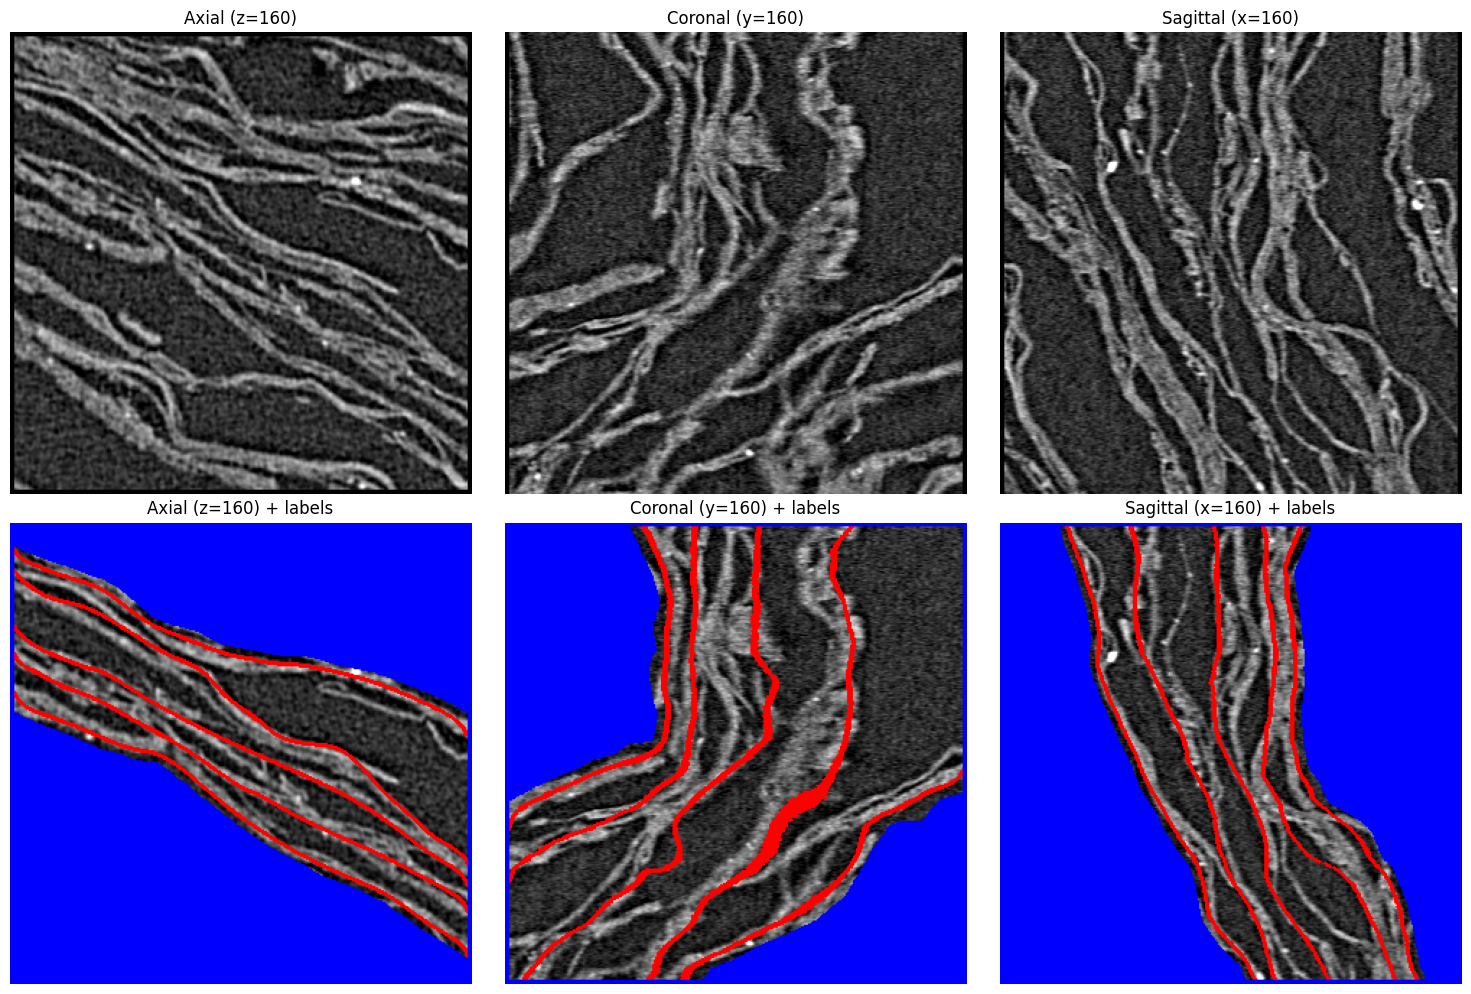

In [4]:
# Visualize 3 orthogonal slices through the volume
mid = sample_img.shape[0] // 2

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Row 1: raw CT slices
axes[0, 0].imshow(sample_img[mid, :, :], cmap="gray")
axes[0, 0].set_title(f"Axial (z={mid})")
axes[0, 1].imshow(sample_img[:, mid, :], cmap="gray")
axes[0, 1].set_title(f"Coronal (y={mid})")
axes[0, 2].imshow(sample_img[:, :, mid], cmap="gray")
axes[0, 2].set_title(f"Sagittal (x={mid})")

# Row 2: label overlay (red = foreground, blue = unlabeled)
for i, (slc_img, slc_lbl, title) in enumerate([
    (sample_img[mid], sample_lbl[mid], f"Axial (z={mid})"),
    (sample_img[:, mid], sample_lbl[:, mid], f"Coronal (y={mid})"),
    (sample_img[:, :, mid], sample_lbl[:, :, mid], f"Sagittal (x={mid})"),
]):
    rgb = np.stack([slc_img]*3, axis=-1).astype(float) / 255.0
    rgb[slc_lbl == 1] = [1, 0, 0]  # foreground = red
    rgb[slc_lbl == 2] = [0, 0, 1]  # unlabeled = blue
    axes[1, i].imshow(rgb)
    axes[1, i].set_title(f"{title} + labels")

for ax in axes.flat:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 3. Dataset

In [5]:
def compute_signed_distance_map(label, mask):
    """
    Compute signed distance transform from ground truth boundary.
    Negative inside foreground, positive outside, zero at boundary.
    Normalized by max distance so values are roughly in [-1, 1].
    Only computed within the valid mask (label != 2).
    """
    fg = label.astype(bool)
    bg = ~fg

    # Distance from foreground boundary (inside -> negative, outside -> positive)
    dist_inside = distance_transform_edt(fg)
    dist_outside = distance_transform_edt(bg)

    signed_dist = dist_outside - dist_inside

    # Normalize by max absolute distance for stable loss scaling
    max_dist = max(np.abs(signed_dist).max(), 1.0)
    signed_dist = signed_dist / max_dist

    # Zero out unlabeled regions
    signed_dist = signed_dist * mask

    return signed_dist.astype(np.float32)


class VesuviusDataset(Dataset):
    """3D volume dataset with random patch cropping for training."""

    def __init__(self, ids, img_dir, lbl_dir, patch_size=128, augment=False, fg_bias=0.0):
        self.ids = ids
        self.img_dir = Path(img_dir)
        self.lbl_dir = Path(lbl_dir)
        self.patch_size = patch_size
        self.augment = augment
        self.fg_bias = fg_bias

    def __len__(self):
        return len(self.ids)

    def _random_crop(self, img, lbl, ps):
        """Extract a random ps^3 patch from the volume."""
        d, h, w = img.shape
        z = random.randint(0, d - ps)
        y = random.randint(0, h - ps)
        x = random.randint(0, w - ps)
        return img[z:z+ps, y:y+ps, x:x+ps], lbl[z:z+ps, y:y+ps, x:x+ps]

    def _fg_crop(self, img, lbl, ps):
        """Extract a ps^3 patch centered on a random foreground voxel."""
        fg_coords = np.argwhere(lbl == 1)
        if len(fg_coords) == 0:
            return self._random_crop(img, lbl, ps)

        # Pick a random foreground voxel
        idx = random.randint(0, len(fg_coords) - 1)
        cz, cy, cx = fg_coords[idx]

        # Center crop on it, clamped to volume bounds
        d, h, w = img.shape
        z = min(max(cz - ps // 2, 0), d - ps)
        y = min(max(cy - ps // 2, 0), h - ps)
        x = min(max(cx - ps // 2, 0), w - ps)
        return img[z:z+ps, y:y+ps, x:x+ps], lbl[z:z+ps, y:y+ps, x:x+ps]

    def __getitem__(self, idx):
        vol_id = self.ids[idx]

        # Load volume and label
        img = tifffile.imread(self.img_dir / f"{vol_id}.tif")
        lbl = tifffile.imread(self.lbl_dir / f"{vol_id}.tif")

        # Patch crop: foreground-biased or random
        if self.augment and random.random() < self.fg_bias:
            img, lbl = self._fg_crop(img, lbl, self.patch_size)
        else:
            img, lbl = self._random_crop(img, lbl, self.patch_size)

        # Normalize to [0, 1]
        img = img.astype(np.float32) / 255.0

        # Mask: True where label is 0 or 1 (valid), False where label is 2 (ignore)
        mask = (lbl != 2).astype(np.float32)

        # Binary label: foreground=1, everything else=0
        label = (lbl == 1).astype(np.float32)

        # Signed distance transform for boundary loss
        dist_map = compute_signed_distance_map(label, mask)

        # Augmentations: random flips and 90-degree rotations
        if self.augment:
            for axis in range(3):
                if random.random() > 0.5:
                    img = np.flip(img, axis=axis).copy()
                    label = np.flip(label, axis=axis).copy()
                    mask = np.flip(mask, axis=axis).copy()
                    dist_map = np.flip(dist_map, axis=axis).copy()

            k = random.randint(0, 3)
            plane_axes = random.choice([(0, 1), (0, 2), (1, 2)])
            if k > 0:
                img = np.rot90(img, k=k, axes=plane_axes).copy()
                label = np.rot90(label, k=k, axes=plane_axes).copy()
                mask = np.rot90(mask, k=k, axes=plane_axes).copy()
                dist_map = np.rot90(dist_map, k=k, axes=plane_axes).copy()

        # Add channel dimension: (1, D, H, W)
        img = torch.from_numpy(img).unsqueeze(0)
        label = torch.from_numpy(label).unsqueeze(0)
        mask = torch.from_numpy(mask).unsqueeze(0)
        dist_map = torch.from_numpy(dist_map).unsqueeze(0)

        return img, (label, mask, dist_map)


# Quick test
test_ds = VesuviusDataset([sample_id], TRAIN_IMG, TRAIN_LBL,
                          patch_size=PATCH_SIZE, augment=True, fg_bias=FG_BIAS)

# Run a few samples and check foreground stats
n_test = 10
fg_counts = []
for i in range(n_test):
    x, (y, m, d) = test_ds[0]
    fg_pct = y.sum().item() / y.numel() * 100
    fg_counts.append(fg_pct)

print(f"Image: {x.shape}, Label: {y.shape}, Mask: {m.shape}, DistMap: {d.shape}")
print(f"Image range: [{x.min():.2f}, {x.max():.2f}]")
print(f"DistMap range: [{d.min():.3f}, {d.max():.3f}]")
print(f"\nForeground-biased sampling test ({n_test} patches, fg_bias={FG_BIAS}):")
print(f"  FG% per patch: {['%.1f' % f for f in fg_counts]}")
print(f"  Mean FG%: {np.mean(fg_counts):.1f}%, patches with >1% FG: {sum(f > 1 for f in fg_counts)}/{n_test}")

Image: torch.Size([1, 160, 160, 160]), Label: torch.Size([1, 160, 160, 160]), Mask: torch.Size([1, 160, 160, 160]), DistMap: torch.Size([1, 160, 160, 160])
Image range: [0.00, 1.00]
DistMap range: [-0.047, 0.724]

Foreground-biased sampling test (10 patches, fg_bias=0.5):
  FG% per patch: ['8.2', '8.1', '8.2', '7.1', '8.0', '8.2', '6.1', '8.6', '7.8', '7.8']
  Mean FG%: 7.8%, patches with >1% FG: 10/10


## 4. DataLoaders

In [6]:
# Split by scroll_id: hold out scroll 26002 for validation (88 volumes)
train_df = pd.read_csv(ROOT / "train.csv")

# Only keep IDs that have both image and label files on disk
available_ids = set(
    int(p.stem) for p in TRAIN_IMG.glob("*.tif")
) & set(
    int(p.stem) for p in TRAIN_LBL.glob("*.tif")
)
train_df = train_df[train_df.id.isin(available_ids)].reset_index(drop=True)

VAL_SCROLL = 26002
val_ids = train_df[train_df.scroll_id == VAL_SCROLL].id.tolist()
trn_ids = train_df[train_df.scroll_id != VAL_SCROLL].id.tolist()

print(f"Train: {len(trn_ids)} volumes, Val: {len(val_ids)} volumes")

trn_ds = VesuviusDataset(trn_ids, TRAIN_IMG, TRAIN_LBL,
                          patch_size=PATCH_SIZE, augment=True, fg_bias=FG_BIAS)
val_ds = VesuviusDataset(val_ids, TRAIN_IMG, TRAIN_LBL,
                          patch_size=PATCH_SIZE, augment=False)

trn_dl = DataLoader(trn_ds, batch_size=BATCH_SIZE, shuffle=True,
                    num_workers=NUM_WORKERS, pin_memory=True)
val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                    num_workers=NUM_WORKERS, pin_memory=True)

dls = DataLoaders(trn_dl, val_dl, device=DEVICE)
print(f"DataLoaders ready. Training fg_bias={FG_BIAS}, Val fg_bias=0 (default).")

Train: 704 volumes, Val: 82 volumes
DataLoaders ready. Training fg_bias=0.5, Val fg_bias=0 (default).


## 5. SegResNet + Attention Gates + Deep Supervision

In [7]:
class AttentionGate3D(nn.Module):
    """
    Attention gate for skip connections (Oktay et al., 2018).

    Learns spatial attention weights that suppress irrelevant encoder features
    before they reach the decoder via skip connections. The gating signal (from
    the decoder path) guides which spatial locations in the skip connection are
    relevant. Particularly useful when foreground is sparse (~4%).
    """

    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Conv3d(F_g, F_int, kernel_size=1, bias=True)
        self.W_x = nn.Conv3d(F_l, F_int, kernel_size=1, bias=True)
        self.psi = nn.Sequential(
            nn.Conv3d(F_int, 1, kernel_size=1, bias=True),
            nn.Sigmoid(),
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        """
        g: gating signal from decoder (upsampled features)
        x: skip connection from encoder
        Returns: attended skip connection (same shape as x)
        """
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi


class SegResNetDSAttn(SegResNet):
    """
    SegResNet with attention gates on skip connections and deep supervision.

    Attention gates: applied at each skip connection to suppress irrelevant
    background features. Channels at each level: [64, 32, 16].

    Deep supervision: auxiliary 1x1 conv heads at intermediate decoder levels
    (64ch @ D/4, 32ch @ D/2). During training, returns [main, aux_0, aux_1].
    During eval, returns only the main output.
    """

    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

        # Channel counts at each decoder level (reversed encoder filters, minus bottleneck)
        filters = [self.init_filters * (2 ** i) for i in range(len(self.blocks_down))]
        up_channels = list(reversed(filters[:-1]))  # [64, 32, 16]

        # Attention gates — one per skip connection
        self.attention_gates = nn.ModuleList([
            AttentionGate3D(F_g=ch, F_l=ch, F_int=max(ch // 2, 4))
            for ch in up_channels
        ])

        # Deep supervision heads — 1x1 conv at each decoder level except the last
        # (the last level is already covered by conv_final)
        self.ds_heads = nn.ModuleList([
            nn.Conv3d(ch, 1, kernel_size=1)
            for ch in up_channels[:-1]  # [64, 32]
        ])

    def decode(self, x, down_x, return_intermediates=False):
        """Decode with attention gates on skip connections."""
        intermediates = []
        for i, (up, upl) in enumerate(zip(self.up_samples, self.up_layers)):
            x_up = up(x)
            skip = down_x[i + 1]
            skip = self.attention_gates[i](g=x_up, x=skip)
            x = x_up + skip
            x = upl(x)

            if return_intermediates and i < len(self.ds_heads):
                intermediates.append(self.ds_heads[i](x))

        if self.use_conv_final:
            x = self.conv_final(x)

        if return_intermediates:
            return x, intermediates
        return x

    def forward(self, x):
        x, down_x = self.encode(x)
        down_x.reverse()

        if self.training:
            main, aux = self.decode(x, down_x, return_intermediates=True)
            return [main] + aux
        else:
            return self.decode(x, down_x)


def create_model_with_suprem_weights(weights_path, device="cpu"):
    """
    Create SegResNetDSAttn and load SuPreM supervised pre-trained weights.

    SuPreM weights load into the base SegResNet layers (convInit, down_layers,
    up_layers, up_samples). New modules (attention_gates, ds_heads) are
    randomly initialized — they're lightweight (~5.5K params).
    """
    model = SegResNetDSAttn(
        spatial_dims=3,
        in_channels=1,
        out_channels=1,
        init_filters=16,
        blocks_down=[1, 2, 2, 4],
        blocks_up=[1, 1, 1],
        dropout_prob=0.2,
    )

    ckpt = torch.load(weights_path, map_location=device, weights_only=False)
    pretrained = ckpt["net"]
    store_dict = model.state_dict()

    loaded, skipped = 0, 0
    for key in pretrained.keys():
        new_key = key.replace("module.", "")
        if new_key in store_dict:
            if "conv_final" in new_key:
                skipped += 1
                continue
            if store_dict[new_key].shape == pretrained[key].shape:
                store_dict[new_key] = pretrained[key]
                loaded += 1
            else:
                print(f"  Shape mismatch: {new_key}")
                skipped += 1
        else:
            skipped += 1

    model.load_state_dict(store_dict)
    print(f"SuPreM weights: loaded {loaded}/{loaded+skipped} params, skipped {skipped} (final conv + new modules)")
    return model


# Create model
model = create_model_with_suprem_weights(PRETRAINED_WEIGHTS)

n_params = sum(p.numel() for p in model.parameters()) / 1e6
n_attn = sum(p.numel() for p in model.attention_gates.parameters())
n_ds = sum(p.numel() for p in model.ds_heads.parameters())
print(f"Total parameters: {n_params:.1f}M")
print(f"  Attention gates: {n_attn:,} params")
print(f"  DS heads: {n_ds:,} params")

# Test forward pass (training mode → returns list)
model.train()
with torch.no_grad():
    dummy = torch.randn(1, 1, PATCH_SIZE, PATCH_SIZE, PATCH_SIZE)
    out = model(dummy)
    print(f"\nTraining mode output: {len(out)} tensors")
    for i, o in enumerate(out):
        label = "main" if i == 0 else f"aux_{i-1}"
        print(f"  {label}: {o.shape}")

# Test eval mode → returns single tensor
model.eval()
with torch.no_grad():
    out = model(dummy)
    print(f"\nEval mode output: {out.shape}")

SuPreM weights: loaded 79/83 params, skipped 4 (final conv + new modules)
Total parameters: 4.7M
  Attention gates: 5,547 params
  DS heads: 98 params



Training mode output: 3 tensors
  main: torch.Size([1, 1, 160, 160, 160])
  aux_0: torch.Size([1, 1, 40, 40, 40])
  aux_1: torch.Size([1, 1, 80, 80, 80])



Eval mode output: torch.Size([1, 1, 160, 160, 160])


## 6. Loss Function

In [8]:
# --- clDice: topology-preserving loss via soft skeletons ---

def soft_erode_3d(img):
    """Soft erosion using min-pooling (negate, max-pool, negate)."""
    return -F.max_pool3d(-img, kernel_size=3, stride=1, padding=1)

def soft_dilate_3d(img):
    """Soft dilation using max-pooling."""
    return F.max_pool3d(img, kernel_size=3, stride=1, padding=1)

def soft_open_3d(img):
    """Soft morphological opening = erode then dilate."""
    return soft_dilate_3d(soft_erode_3d(img))

def soft_skeleton_3d(img, iters=5):
    """
    Compute soft skeleton via iterative erosion.
    skel = sum_i [ ReLU(erode^i(img) - open(erode^i(img))) ]
    """
    skel = F.relu(img - soft_open_3d(img))
    for _ in range(iters):
        img = soft_erode_3d(img)
        delta = F.relu(img - soft_open_3d(img))
        skel = skel + delta
    return skel

def soft_cldice(pred_sig, target, iters=5, smooth=1.0):
    """
    Compute clDice on 2x-downsampled volumes for memory efficiency.
    Topology is a coarse structural property, so 64^3 captures it well.
    """
    pred_ds = F.avg_pool3d(pred_sig, kernel_size=2)
    with torch.no_grad():
        target_ds = F.avg_pool3d(target, kernel_size=2)

    skel_pred = soft_skeleton_3d(pred_ds, iters=iters)
    with torch.no_grad():
        skel_target = soft_skeleton_3d(target_ds, iters=iters)

    tprec = ((skel_pred * target_ds).sum() + smooth) / (skel_pred.sum() + smooth)
    tsens = ((skel_target * pred_ds).sum() + smooth) / (skel_target.sum() + smooth)

    cldice = 2.0 * tprec * tsens / (tprec + tsens + 1e-8)
    return cldice


# --- Boundary loss via signed distance transform ---

def boundary_loss(pred_sig, dist_map, mask):
    """
    Boundary loss: penalizes predictions far from the ground truth boundary.
    Uses signed distance transform (negative inside GT, positive outside).
    """
    loss = (pred_sig * dist_map * mask).sum() / (mask.sum() + 1e-8)
    return loss


class MaskedCombinedLoss(nn.Module):
    """
    Combined loss with deep supervision support.

    Main output: 0.2*BCE + 0.2*Dice + 0.3*clDice + 0.3*Boundary (full loss)
    Auxiliary outputs: BCE + Dice only (upsampled to full res, weighted by ds_weight)

    When pred is a list [main, aux_0, aux_1], applies full loss to main and
    simple BCE+Dice to each auxiliary. When pred is a single tensor, applies
    full loss only.
    """

    def __init__(self, bce_weight=0.2, dice_weight=0.2, cldice_weight=0.3,
                 boundary_weight=0.3, smooth=1.0, skel_iters=5, ds_weight=0.3):
        super().__init__()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight
        self.cldice_weight = cldice_weight
        self.boundary_weight = boundary_weight
        self.smooth = smooth
        self.skel_iters = skel_iters
        self.ds_weight = ds_weight

    def _full_loss(self, pred, target_tuple):
        """Full combined loss: BCE + Dice + clDice + Boundary."""
        target, mask, dist_map = target_tuple
        pred_sig = torch.sigmoid(pred)
        pred_masked = pred_sig * mask
        target_masked = target * mask

        bce = F.binary_cross_entropy_with_logits(pred, target, reduction='none')
        bce = (bce * mask).sum() / (mask.sum() + 1e-8)

        intersection = (pred_masked * target_masked).sum()
        dice = (2.0 * intersection + self.smooth) / (
            pred_masked.sum() + target_masked.sum() + self.smooth
        )
        dice_loss = 1.0 - dice

        cldice = soft_cldice(pred_masked, target_masked,
                             iters=self.skel_iters, smooth=self.smooth)
        cldice_loss = 1.0 - cldice

        bd_loss = boundary_loss(pred_sig, dist_map, mask)

        return (self.bce_weight * bce +
                self.dice_weight * dice_loss +
                self.cldice_weight * cldice_loss +
                self.boundary_weight * bd_loss)

    def _simple_loss(self, pred, target_tuple):
        """Simple BCE + Dice loss for auxiliary deep supervision heads."""
        target, mask, _dist_map = target_tuple
        pred_sig = torch.sigmoid(pred)
        pred_masked = pred_sig * mask
        target_masked = target * mask

        bce = F.binary_cross_entropy_with_logits(pred, target, reduction='none')
        bce = (bce * mask).sum() / (mask.sum() + 1e-8)

        intersection = (pred_masked * target_masked).sum()
        dice = (2.0 * intersection + self.smooth) / (
            pred_masked.sum() + target_masked.sum() + self.smooth
        )
        dice_loss = 1.0 - dice

        return 0.5 * bce + 0.5 * dice_loss

    def forward(self, pred, target_tuple):
        if isinstance(pred, (list, tuple)):
            # Deep supervision: full loss on main, simple loss on auxiliaries
            main_loss = self._full_loss(pred[0], target_tuple)

            aux_loss = 0.0
            for aux_pred in pred[1:]:
                # Upsample auxiliary prediction to full resolution
                aux_up = F.interpolate(aux_pred, size=pred[0].shape[2:],
                                       mode='trilinear', align_corners=False)
                aux_loss += self._simple_loss(aux_up, target_tuple)

            if len(pred) > 1:
                aux_loss /= (len(pred) - 1)

            return main_loss + self.ds_weight * aux_loss
        else:
            return self._full_loss(pred, target_tuple)


class MaskedDiceMetric(Metric):
    """Dice coefficient metric (masked) for fastai Learner. Handles DS list output."""
    def __init__(self):
        self.reset()

    def reset(self):
        self.intersection = 0.0
        self.union = 0.0

    def accumulate(self, learn):
        pred = learn.pred
        if isinstance(pred, (list, tuple)):
            pred = pred[0]  # use main output only
        pred = torch.sigmoid(pred) > 0.5
        target, mask, _dist = learn.y
        pred_m = pred * mask
        tgt_m = target * mask
        self.intersection += (pred_m * tgt_m).sum().item()
        self.union += pred_m.sum().item() + tgt_m.sum().item()

    @property
    def value(self):
        return (2.0 * self.intersection + 1.0) / (self.union + 1.0)

    @property
    def name(self):
        return "dice"


# --- Sliding window inference (needed by CompetitionMetric during training) ---

def sliding_window_inference(model, volume, patch_size=160, stride=80, device="cuda"):
    """
    Run inference on a full 320^3 volume using overlapping patches.
    Overlapping regions are averaged for smoother predictions.
    """
    D, H, W = volume.shape
    ps = patch_size

    output = np.zeros((D, H, W), dtype=np.float32)
    counts = np.zeros((D, H, W), dtype=np.float32)

    def _positions(length, ps, stride):
        pos = list(range(0, length - ps, stride))
        if not pos or pos[-1] + ps < length:
            pos.append(length - ps)
        return pos

    z_pos = _positions(D, ps, stride)
    y_pos = _positions(H, ps, stride)
    x_pos = _positions(W, ps, stride)

    with torch.no_grad(), torch.amp.autocast("cuda"):
        for z in z_pos:
            for y in y_pos:
                for x in x_pos:
                    patch = volume[z:z+ps, y:y+ps, x:x+ps]
                    patch_t = torch.from_numpy(patch).float().unsqueeze(0).unsqueeze(0).to(device) / 255.0
                    logits = model(patch_t)
                    prob = torch.sigmoid(logits).squeeze().cpu().numpy()
                    output[z:z+ps, y:y+ps, x:x+ps] += prob
                    counts[z:z+ps, y:y+ps, x:x+ps] += 1.0

    output /= counts
    return output


# --- TTA: 7-fold test-time augmentation ---

def sliding_window_inference_tta(model, volume, patch_size=160, stride=80, device="cuda"):
    """
    7-fold TTA: original + 3 axis flips + 3 HW-plane rotations (90/180/270).
    """
    probs = []
    probs.append(sliding_window_inference(model, volume, patch_size, stride, device))

    for axis in range(3):
        flipped = np.flip(volume, axis=axis).copy()
        prob = sliding_window_inference(model, flipped, patch_size, stride, device)
        probs.append(np.flip(prob, axis=axis).copy())

    for k in [1, 2, 3]:
        rotated = np.rot90(volume, k=k, axes=(1, 2)).copy()
        prob = sliding_window_inference(model, rotated, patch_size, stride, device)
        probs.append(np.rot90(prob, k=-k, axes=(1, 2)).copy())

    return np.mean(probs, axis=0)


# --- Hysteresis thresholding ---

def hysteresis_threshold(prob, t_low=0.45, t_high=0.85):
    """Dual-threshold seed-and-propagate with 26-connectivity."""
    strong = prob >= t_high
    weak = prob >= t_low
    struct = generate_binary_structure(3, 3)
    return binary_propagation(strong, structure=struct, mask=weak).astype(np.uint8)


# --- Anisotropic closing ---

def build_anisotropic_struct(z_radius=2, xy_radius=1):
    """Build a z-heavy structuring element for layered papyrus structure."""
    sz = 2 * z_radius + 1
    sxy = 2 * xy_radius + 1
    struct = np.zeros((sz, sxy, sxy), dtype=bool)
    cy, cx = xy_radius, xy_radius
    for y in range(sxy):
        for x in range(sxy):
            if (y - cy)**2 + (x - cx)**2 <= xy_radius**2:
                struct[:, y, x] = True
    return struct


# --- Competition metric ---

class CompetitionMetric(Metric):
    """
    Exact competition metric: 0.30*TopoScore + 0.35*SurfaceDice@tau=2 + 0.35*VOI
    Handles DS list output (model is set to eval mode -> returns single tensor).
    """
    def __init__(self, val_ids, img_dir, lbl_dir, n_volumes=5, t_low=0.45,
                 t_high=0.85, patch_size=160, stride=80, downsample=4):
        self.val_ids = val_ids[:n_volumes]
        self.img_dir = Path(img_dir)
        self.lbl_dir = Path(lbl_dir)
        self.t_low = t_low
        self.t_high = t_high
        self.patch_size = patch_size
        self.stride = stride
        self.downsample = downsample
        self._model = None
        self.reset()

    def reset(self):
        self._model = None

    def accumulate(self, learn):
        self._model = learn.model

    @property
    def value(self):
        if self._model is None:
            return 0.0

        self._model.eval()
        scores = []
        for vid in self.val_ids:
            img = tifffile.imread(self.img_dir / f"{vid}.tif")
            lbl = tifffile.imread(self.lbl_dir / f"{vid}.tif")

            prob = sliding_window_inference(
                self._model, img,
                patch_size=self.patch_size,
                stride=self.stride,
                device=next(self._model.parameters()).device,
            )
            pred = hysteresis_threshold(prob, self.t_low, self.t_high)

            ds = self.downsample
            if ds > 1:
                scale = 1.0 / ds
                pred = scipy_zoom(pred, scale, order=0).astype(np.uint8)
                lbl = scipy_zoom(lbl, scale, order=0).astype(np.uint8)

            report = compute_leaderboard_score(
                pred, lbl,
                ignore_label=2,
                spacing=(1, 1, 1),
                surface_tolerance=2.0,
                voi_alpha=0.3,
                combine_weights=(0.3, 0.35, 0.35),
            )
            scores.append(report.score)

        self._model.train()
        return float(np.mean(scores))

    @property
    def name(self):
        return "comp_score"


# --- 4-group discriminative LR splitter ---

def segresnet_splitter_v10b(model):
    """Split SegResNetDSAttn into 4 param groups for per-module lr_find."""
    encoder = list(model.convInit.parameters()) + list(model.down_layers.parameters())
    decoder = list(model.up_layers.parameters()) + list(model.up_samples.parameters())
    new_modules = list(model.attention_gates.parameters()) + list(model.ds_heads.parameters())
    head = list(model.conv_final.parameters())
    return [encoder, decoder, new_modules, head]


# --- Selective freeze helpers for per-group lr_find ---

def freeze_groups(learn, freeze_indices):
    """Freeze specific parameter groups by index, unfreeze the rest."""
    for i, pg in enumerate(learn.opt.param_lists):
        for p in pg:
            p.requires_grad_(i not in freeze_indices)

def unfreeze_all(learn):
    """Unfreeze all parameter groups."""
    for pg in learn.opt.param_lists:
        for p in pg:
            p.requires_grad_(True)


print("Loss (0.2*BCE + 0.2*Dice + 0.3*clDice + 0.3*Boundary) + deep supervision")
print(f"  Main output: full loss")
print(f"  Auxiliary outputs: BCE + Dice, weight={DS_WEIGHT}")
print(f"  Attention gates on all 3 skip connections")
print(f"CompetitionMetric: Kaggle score on {N_VAL_VOLUMES} val volumes, {METRIC_DOWNSAMPLE}x downsample")
print(f"Splitter: 4 groups (encoder / decoder / new_modules / head)")
print(f"  freeze_groups() / unfreeze_all() helpers for per-group lr_find")

Loss (0.2*BCE + 0.2*Dice + 0.3*clDice + 0.3*Boundary) + deep supervision
  Main output: full loss
  Auxiliary outputs: BCE + Dice, weight=0.3
  Attention gates on all 3 skip connections
CompetitionMetric: Kaggle score on 5 val volumes, 4x downsample
Splitter: 4 groups (encoder / decoder / new_modules / head)
  freeze_groups() / unfreeze_all() helpers for per-group lr_find


## 7. Training

In [9]:
model = create_model_with_suprem_weights(PRETRAINED_WEIGHTS, device=DEVICE)
model = model.to(DEVICE)
loss_fn = MaskedCombinedLoss(ds_weight=DS_WEIGHT)

comp_metric = CompetitionMetric(
    val_ids, TRAIN_IMG, TRAIN_LBL,
    n_volumes=N_VAL_VOLUMES, t_low=T_LOW, t_high=T_HIGH,
    patch_size=PATCH_SIZE, stride=STRIDE, downsample=METRIC_DOWNSAMPLE,
)

learn = Learner(
    dls,
    model,
    loss_func=loss_fn,
    metrics=[comp_metric],
    splitter=segresnet_splitter_v10b,
    cbs=[
        MixedPrecision(),
        SaveModelCallback(monitor="comp_score", comp=np.greater, fname="best_segresnet_v10b"),
    ],
    path=CKPT_DIR,
)

print("Learner ready (SegResNetDSAttn with 4 param groups).")
print(f"  Group 0 (encoder): convInit + down_layers [pretrained]")
print(f"  Group 1 (decoder): up_layers + up_samples [pretrained]")
print(f"  Group 2 (new_modules): attention_gates + ds_heads [random init]")
print(f"  Group 3 (head): conv_final [random init]")
print(f"  Deep supervision: {len(model.ds_heads)} auxiliary heads, weight={DS_WEIGHT}")
print(f"  Attention gates: {len(model.attention_gates)} gates")
print(f"Checkpoint: best_segresnet_v10b")

SuPreM weights: loaded 79/83 params, skipped 4 (final conv + new modules)
Learner ready (SegResNetDSAttn with 4 param groups).
  Group 0 (encoder): convInit + down_layers [pretrained]
  Group 1 (decoder): up_layers + up_samples [pretrained]
  Group 2 (new_modules): attention_gates + ds_heads [random init]
  Group 3 (head): conv_final [random init]
  Deep supervision: 2 auxiliary heads, weight=0.3
  Attention gates: 3 gates
Checkpoint: best_segresnet_v10b



--- lr_find for group 3 (head) ---
  Frozen: ['encoder', 'decoder', 'new_modules']
  Range: [1e-07, 1e-01]


  Valley LR: 5.50e-03
SuPreM weights: loaded 79/83 params, skipped 4 (final conv + new modules)

--- lr_find for group 2 (new_modules) ---
  Frozen: ['encoder', 'decoder', 'head']
  Range: [1e-07, 1e-01]


  Valley LR: 2.40e-03
SuPreM weights: loaded 79/83 params, skipped 4 (final conv + new modules)

--- lr_find for group 1 (decoder) ---
  Frozen: ['encoder', 'new_modules', 'head']
  Range: [1e-08, 1e-02]


  Valley LR: 9.12e-05
SuPreM weights: loaded 79/83 params, skipped 4 (final conv + new modules)

--- lr_find for group 0 (encoder) ---
  Frozen: ['decoder', 'new_modules', 'head']
  Range: [1e-09, 1e-03]


  Valley LR: 9.12e-06
SuPreM weights: loaded 79/83 params, skipped 4 (final conv + new modules)


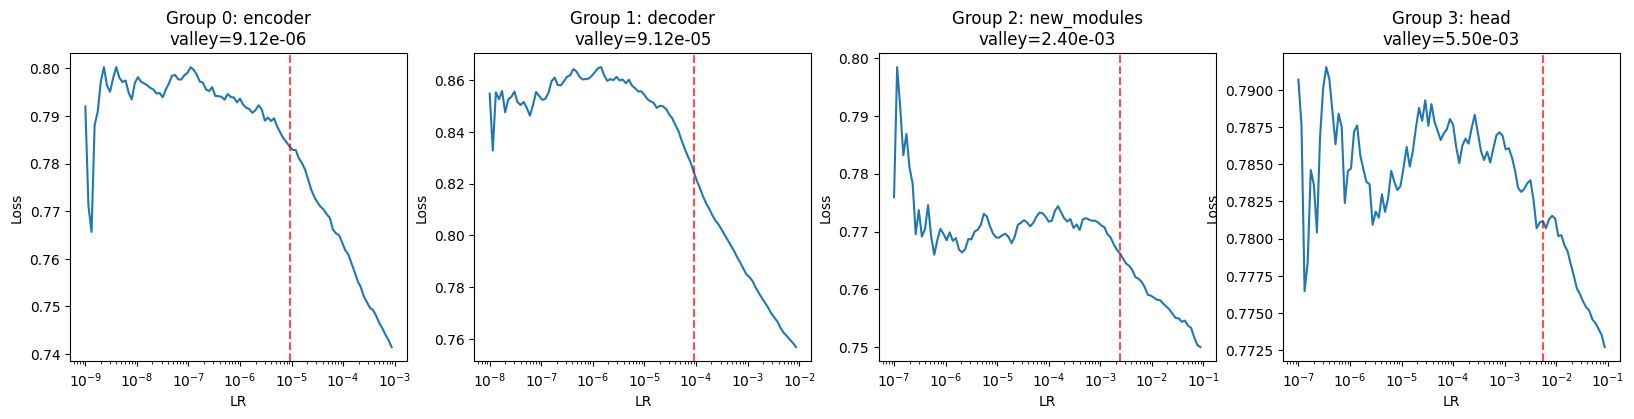

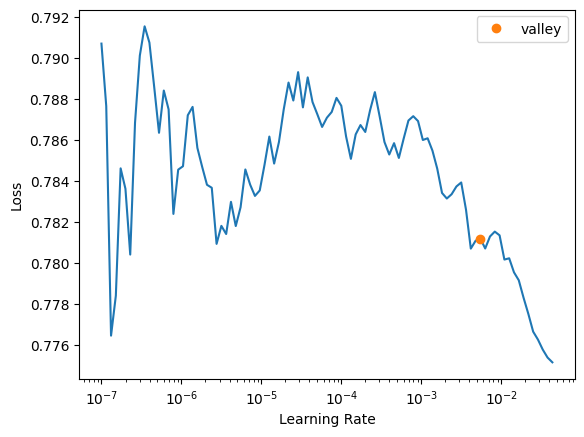

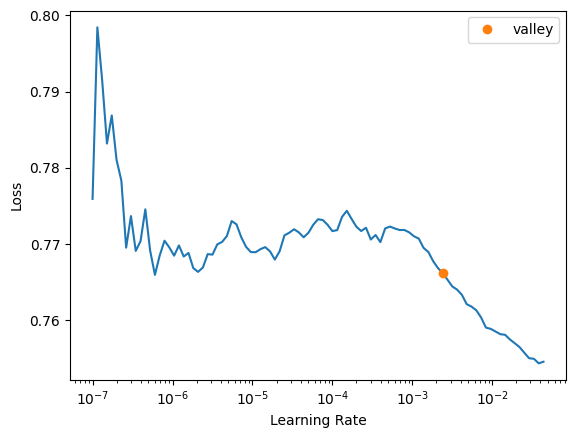

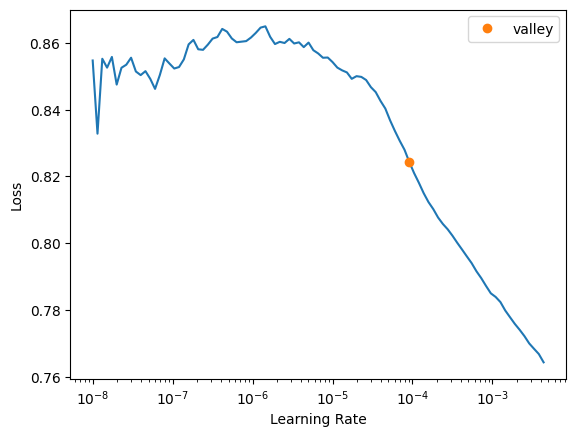

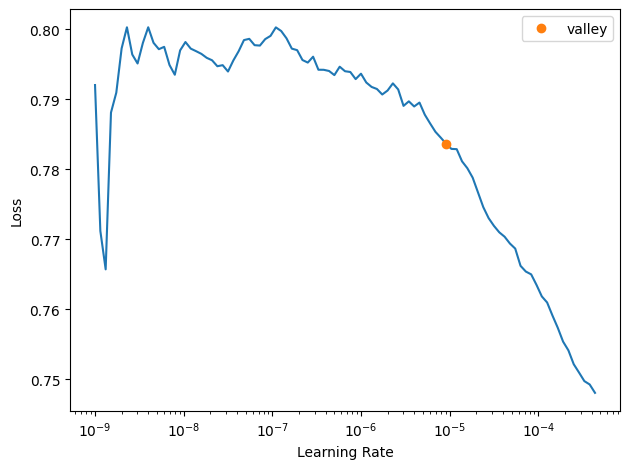


Per-group lr_find results:
  Group 0 (encoder):     9.12e-06
  Group 1 (decoder):     9.12e-05
  Group 2 (new_modules): 2.40e-03
  Group 3 (head):        5.50e-03

Training will use: lr_max=[9.12e-06, 9.12e-05, 2.40e-03, 5.50e-03]


In [10]:
# --- Per-group lr_find ---
# Run lr_find 4 times, each time freezing all groups except one.
# This finds the optimal LR for each group independently.
#
# Group 0 (encoder): pretrained SuPreM — needs very low LR
# Group 1 (decoder): pretrained SuPreM — needs low LR
# Group 2 (new_modules): random init (attn gates + DS heads) — needs higher LR
# Group 3 (head): random init (conv_final) — needs higher LR

# We need the optimizer to exist before we can freeze groups.
# Creating it by calling create_opt:
learn.create_opt()

group_names = ["encoder", "decoder", "new_modules", "head"]
group_ranges = [
    (1e-9, 1e-3),   # encoder (pretrained)
    (1e-8, 1e-2),   # decoder (pretrained)
    (1e-7, 1e-1),   # new_modules (random init)
    (1e-7, 1e-1),   # head (random init)
]

lr_results = {}
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for group_idx in [3, 2, 1, 0]:  # head first, encoder last (least disruptive order)
    name = group_names[group_idx]
    lr_min, lr_max = group_ranges[group_idx]

    # Freeze all groups except this one
    freeze_indices = set(range(4)) - {group_idx}
    freeze_groups(learn, freeze_indices)

    print(f"\n--- lr_find for group {group_idx} ({name}) ---")
    print(f"  Frozen: {[group_names[i] for i in sorted(freeze_indices)]}")
    print(f"  Range: [{lr_min:.0e}, {lr_max:.0e}]")

    # Run lr_find
    result = learn.lr_find(start_lr=lr_min, end_lr=lr_max, num_it=100)
    valley_lr = result.valley
    lr_results[group_idx] = valley_lr
    print(f"  Valley LR: {valley_lr:.2e}")

    # Plot
    ax = axes[group_idx]
    ax.plot(learn.recorder.lrs, learn.recorder.losses)
    ax.set_xscale('log')
    ax.set_title(f"Group {group_idx}: {name}\nvalley={valley_lr:.2e}")
    ax.set_xlabel("LR")
    ax.set_ylabel("Loss")
    ax.axvline(valley_lr, color='r', linestyle='--', alpha=0.7)

    # Re-create model + learner to reset weights after lr_find
    model = create_model_with_suprem_weights(PRETRAINED_WEIGHTS, device=DEVICE)
    model = model.to(DEVICE)
    learn.model = model
    learn.create_opt()

# Unfreeze all after lr_find
unfreeze_all(learn)

plt.tight_layout()
plt.savefig(str(ROOT / "logs" / "v10b_lr_find.png"), dpi=150)
plt.show()

# Extract LRs
lr_enc = lr_results[0]
lr_dec = lr_results[1]
lr_new = lr_results[2]
lr_head = lr_results[3]

print(f"\n{'='*50}")
print(f"Per-group lr_find results:")
print(f"  Group 0 (encoder):     {lr_enc:.2e}")
print(f"  Group 1 (decoder):     {lr_dec:.2e}")
print(f"  Group 2 (new_modules): {lr_new:.2e}")
print(f"  Group 3 (head):        {lr_head:.2e}")
print(f"{'='*50}")
print(f"\nTraining will use: lr_max=[{lr_enc:.2e}, {lr_dec:.2e}, {lr_new:.2e}, {lr_head:.2e}]")

In [ ]:
# Training with hardcoded per-group LRs (eyeballed from lr_find plots)
# lr_find valley picks too aggressively (~100x too high for each group),
# causing the model to peak at epoch 1 and never improve — same pattern as Run 8.
# Hardcoding based on visual first-valley in each lr_find plot.

lr_enc  = 1e-7   # Group 0 (encoder):     pretrained, very gentle
lr_dec  = 1e-6   # Group 1 (decoder):     pretrained, gentle
lr_new  = 1e-5   # Group 2 (new_modules): random init (attn gates + DS heads)
lr_head = 1e-4   # Group 3 (head):        random init (conv_final)

print(f"Training {EPOCHS} epochs with hardcoded per-group LRs (eyeballed from lr_find plots):")
print(f"  Group 0 (encoder):     {lr_enc:.2e}  (valley was 9.12e-06)")
print(f"  Group 1 (decoder):     {lr_dec:.2e}  (valley was 9.12e-05)")
print(f"  Group 2 (new_modules): {lr_new:.2e}  (valley was 2.40e-03)")
print(f"  Group 3 (head):        {lr_head:.2e}  (valley was 5.50e-03)")
print(f"  Deep supervision:      {DS_WEIGHT} weight per aux head")

learn.fit_one_cycle(EPOCHS, lr_max=[lr_enc, lr_dec, lr_new, lr_head])

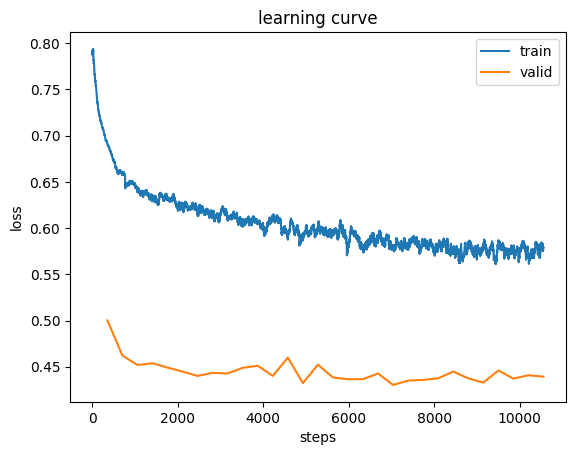

In [12]:
# Plot training curves
learn.recorder.plot_loss()
plt.show()

## 8. Inference & Submission

In [13]:
# Load best model (selected by competition metric, not dice)
learn.load("best_segresnet_v10b")
model = learn.model.eval()
print("Best model loaded (selected by comp_score).")

Best model loaded (selected by comp_score).


/home/mongomatt/Projects/vesuvius/vesuvius/lib/python3.12/site-packages/fastai/learner.py:67: UserWarning: Saved file doesn't contain an optimizer state.
  elif with_opt: warn("Saved file doesn't contain an optimizer state.")


In [14]:
# sliding_window_inference() and sliding_window_inference_tta() are defined in cell 14
print("Inference functions defined above:")
print(f"  sliding_window_inference — patch_size={PATCH_SIZE}, stride={STRIDE}")
print(f"  sliding_window_inference_tta — 7-fold TTA (original + 3 flips + 3 rotations)")
print(f"  TTA is {'ENABLED' if USE_TTA else 'DISABLED'} for final inference")

Inference functions defined above:
  sliding_window_inference — patch_size=160, stride=80
  sliding_window_inference_tta — 7-fold TTA (original + 3 flips + 3 rotations)
  TTA is ENABLED for final inference


### Hysteresis Parameter Sweep

Sweep T_low values with fixed T_high=0.85 to find optimal hysteresis thresholds.
Uses dice as a fast proxy, then verifies the best with comp_score on a few volumes.

In [15]:
# --- Post-processing pipeline: hysteresis + anisotropic closing + dust removal ---

def postprocess(probs, t_low=0.45, t_high=0.85, z_radius=2, xy_radius=1, min_size=100):
    """
    Full post-processing pipeline:
    1. Hysteresis thresholding (seed-and-propagate)
    2. Anisotropic morphological closing (z-heavy structuring element)
    3. Dust removal (remove small connected components)
    """
    # 1. Hysteresis thresholding
    binary = hysteresis_threshold(probs, t_low, t_high)

    # 2. Anisotropic closing
    struct = build_anisotropic_struct(z_radius, xy_radius)
    closed = binary_closing(binary, structure=struct)

    # 3. Dust removal — remove small connected components
    labeled, n_components = scipy_label(closed)
    if n_components > 0:
        component_sizes = np.bincount(labeled.ravel())
        small_mask = component_sizes < min_size
        small_mask[0] = False  # don't remove background
        closed[small_mask[labeled]] = 0

    return closed.astype(np.uint8)


def compute_dice_at_threshold(prob, label_vol, t_low, t_high):
    """Compute masked dice for a full volume using hysteresis thresholding."""
    mask = (label_vol != 2)
    target = (label_vol == 1)
    pred = hysteresis_threshold(prob, t_low, t_high).astype(bool)

    pred_m = pred & mask
    tgt_m = target & mask

    intersection = (pred_m & tgt_m).sum()
    union = pred_m.sum() + tgt_m.sum()
    return (2.0 * intersection + 1.0) / (union + 1.0)


# --- T_low sweep with fixed T_high ---
n_sweep = min(10, len(val_ids))
sweep_ids = val_ids[:n_sweep]
t_low_values = [0.35, 0.40, 0.45, 0.50, 0.55]
t_high_fixed = T_HIGH

print(f"Sweeping T_low in {t_low_values} with T_high={t_high_fixed} on {n_sweep} val volumes...")

# Pre-compute probability maps for all sweep volumes
prob_maps = {}
for i, vid in enumerate(sweep_ids):
    img = tifffile.imread(TRAIN_IMG / f"{vid}.tif")
    prob_maps[vid] = sliding_window_inference(model, img, patch_size=PATCH_SIZE, stride=STRIDE, device=DEVICE)
    print(f"  [{i+1}/{n_sweep}] {vid} — prob map computed")

# Sweep T_low using dice as fast proxy
results = {t: [] for t in t_low_values}
for vid in sweep_ids:
    lbl = tifffile.imread(TRAIN_LBL / f"{vid}.tif")
    prob = prob_maps[vid]
    for t in t_low_values:
        dice = compute_dice_at_threshold(prob, lbl, t, t_high_fixed)
        results[t].append(dice)

print(f"\n{'T_low':>8} {'T_high':>8} {'Dice (mean)':>12}")
print("-" * 30)
best_t_low, best_dice = T_LOW, 0
for t in t_low_values:
    mean_dice = np.mean(results[t])
    print(f"{t:>8.2f} {t_high_fixed:>8.2f} {mean_dice:>12.4f}")
    if mean_dice > best_dice:
        best_dice = mean_dice
        best_t_low = t

print(f"\nBest T_low by dice proxy: {best_t_low} (dice={best_dice:.4f})")

# Verify best with comp_score on 3 volumes
n_verify = min(3, n_sweep)
verify_scores = []
for vid in sweep_ids[:n_verify]:
    prob = prob_maps[vid]
    lbl = tifffile.imread(TRAIN_LBL / f"{vid}.tif")
    pred = postprocess(prob, t_low=best_t_low, t_high=t_high_fixed,
                       z_radius=CLOSING_Z_RADIUS, xy_radius=CLOSING_XY_RADIUS,
                       min_size=DUST_MIN_SIZE)

    ds = METRIC_DOWNSAMPLE
    pred_ds = scipy_zoom(pred, 1.0/ds, order=0).astype(np.uint8)
    lbl_ds = scipy_zoom(lbl, 1.0/ds, order=0).astype(np.uint8)

    report = compute_leaderboard_score(
        pred_ds, lbl_ds, ignore_label=2, spacing=(1,1,1),
        surface_tolerance=2.0, voi_alpha=0.3, combine_weights=(0.3, 0.35, 0.35),
    )
    verify_scores.append(report.score)
    print(f"  Verify {vid}: comp_score={report.score:.4f}")

print(f"\nVerification comp_score (mean of {n_verify}): {np.mean(verify_scores):.4f}")

BEST_T_LOW = best_t_low
BEST_T_HIGH = t_high_fixed
print(f"\nFinal thresholds: T_low={BEST_T_LOW}, T_high={BEST_T_HIGH}")

Sweeping T_low in [0.35, 0.4, 0.45, 0.5, 0.55] with T_high=0.85 on 10 val volumes...


  [1/10] 26894125 — prob map computed


  [2/10] 105796630 — prob map computed


  [3/10] 327851248 — prob map computed


  [4/10] 418613908 — prob map computed


...

  [10/10] 730065526 — prob map computed



   T_low   T_high  Dice (mean)
------------------------------
    0.35     0.85       0.2802
    0.40     0.85       0.2827
    0.45     0.85       0.2739
    0.50     0.85       0.1984
    0.55     0.85       0.0253

Best T_low by dice proxy: 0.4 (dice=0.2827)


  Verify 26894125: comp_score=0.5757


  Verify 105796630: comp_score=0.5484


  Verify 327851248: comp_score=0.5888

Verification comp_score (mean of 3): 0.5710

Final thresholds: T_low=0.4, T_high=0.85


In [16]:
# Run inference on test volumes with TTA + hysteresis + anisotropic closing + dust removal
import time

test_df = pd.read_csv(ROOT / "test.csv")
submission_dir = ROOT / "submission"
submission_dir.mkdir(exist_ok=True)

infer_fn = sliding_window_inference_tta if USE_TTA else sliding_window_inference
print(f"Inference mode: {'TTA (7-fold)' if USE_TTA else 'standard'}")
print(f"Post-processing: hysteresis(T_low={BEST_T_LOW}, T_high={BEST_T_HIGH}) + "
      f"aniso_closing(z={CLOSING_Z_RADIUS}, xy={CLOSING_XY_RADIUS}) + "
      f"dust_removal(min={DUST_MIN_SIZE})")

for _, row in test_df.iterrows():
    vol_id = row.id
    img_path = TEST_IMG / f"{vol_id}.tif"
    if not img_path.exists():
        print(f"Skipping {vol_id}: file not found")
        continue

    print(f"\nPredicting {vol_id}...")
    img = tifffile.imread(img_path)

    t0 = time.time()
    prob = infer_fn(model, img, patch_size=PATCH_SIZE, stride=STRIDE, device=DEVICE)
    t_infer = time.time() - t0

    pred = postprocess(prob, t_low=BEST_T_LOW, t_high=BEST_T_HIGH,
                       z_radius=CLOSING_Z_RADIUS, xy_radius=CLOSING_XY_RADIUS,
                       min_size=DUST_MIN_SIZE)

    out_path = submission_dir / f"{vol_id}.tif"
    tifffile.imwrite(out_path, pred)
    fg = pred.sum()
    print(f"  Inference: {t_infer:.1f}s")
    print(f"  Hysteresis: T_low={BEST_T_LOW}, T_high={BEST_T_HIGH}")
    print(f"  Saved {out_path} — shape: {pred.shape}, fg: {fg}/{pred.size} ({fg/pred.size*100:.1f}%)")

print("\nInference done.")

Inference mode: TTA (7-fold)
Post-processing: hysteresis(T_low=0.4, T_high=0.85) + aniso_closing(z=2, xy=1) + dust_removal(min=100)

Predicting 1407735...


  Inference: 35.1s
  Hysteresis: T_low=0.4, T_high=0.85
  Saved /home/mongomatt/Projects/vesuvius/submission/1407735.tif — shape: (320, 320, 320), fg: 0/32768000 (0.0%)

Inference done.


In [17]:
# Create submission.zip
zip_path = ROOT / "submission.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for tif in submission_dir.glob("*.tif"):
        zf.write(tif, tif.name)

print(f"Submission zip created: {zip_path}")
print(f"Size: {zip_path.stat().st_size / 1e6:.1f} MB")

Submission zip created: /home/mongomatt/Projects/vesuvius/submission.zip
Size: 0.0 MB


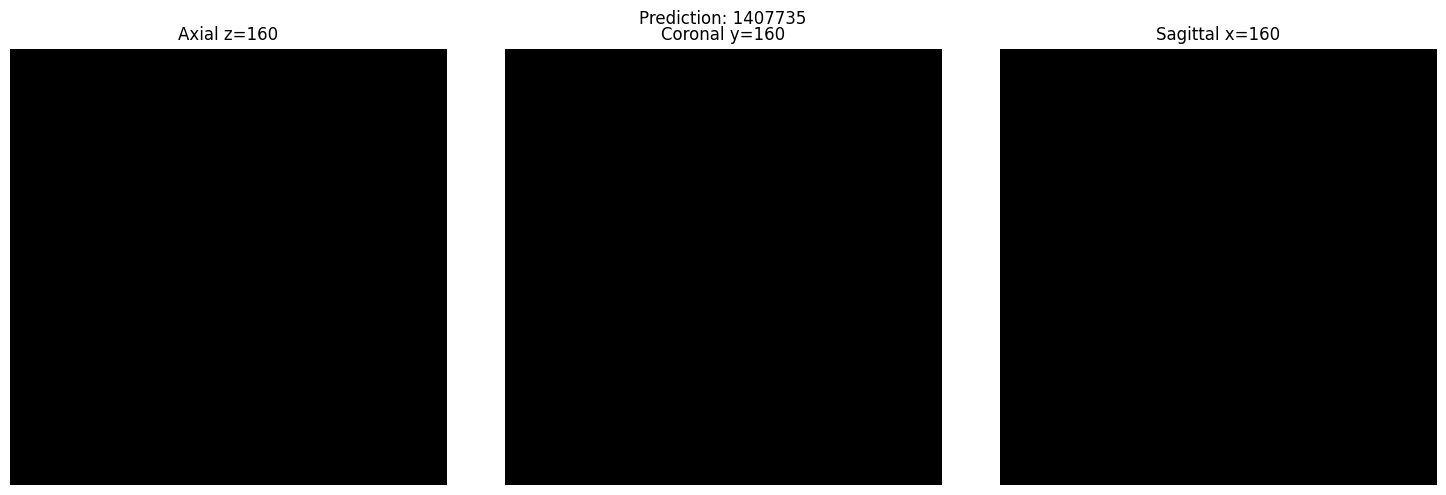

In [18]:
# Visualize a prediction (if test data is available)
if list(submission_dir.glob("*.tif")):
    pred_path = list(submission_dir.glob("*.tif"))[0]
    pred_vol = tifffile.imread(pred_path)
    mid = pred_vol.shape[0] // 2

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(pred_vol[mid], cmap="gray")
    axes[0].set_title(f"Axial z={mid}")
    axes[1].imshow(pred_vol[:, mid], cmap="gray")
    axes[1].set_title(f"Coronal y={mid}")
    axes[2].imshow(pred_vol[:, :, mid], cmap="gray")
    axes[2].set_title(f"Sagittal x={mid}")
    for ax in axes:
        ax.axis("off")
    plt.suptitle(f"Prediction: {pred_path.stem}")
    plt.tight_layout()
    plt.show()